# Лабораторная работа №3: Понижение размерности

#  Теоретические определения

## Что такое высокая размерность данных?
**Высокая размерность** — это ситуация, когда количество признаков (факторов, переменных) в наборе данных сопоставимо или превышает количество наблюдений. Это приводит к:
- "Проклятию размерности" — экспоненциальному росту объёма пространства при добавлении признаков
- Разреженности данных — точки становятся далёкими друг от друга
- Переобучению моделей машинного обучения
- Увеличению вычислительных затрат

## Метод главных компонент (PCA)
**PCA (Principal Component Analysis)** — линейный метод понижения размерности, который:
1. Находит новые оси (главные компоненты), максимизирующие дисперсию данных
2. Проецирует данные на подпространство меньшей размерности
3. Сохраняет максимальное количество информации при сжатии



## t-SNE и UMAP
**t-SNE (t-distributed Stochastic Neighbor Embedding)** — нелинейный метод визуализации, сохраняющий локальные структуры данных.

**UMAP (Uniform Manifold Approximation and Projection)** — современный метод, сохраняющий как локальную, так и глобальную структуру, работает быстрее t-SNE.

In [81]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Все библиотеки успешно импортированы")

Все библиотеки успешно импортированы


## Загрузка и предобработка данных

### Описание датасета Online Retail
Датасет содержит транзакции онлайн-магазина с полями:
- `InvoiceNo` — номер счёта
- `StockCode` — код товара
- `Description` — описание товара
- `Quantity` — количество
- `InvoiceDate` — дата и время
- `UnitPrice` — цена за единицу
- `CustomerID` — ID клиента
- `Country` — страна

### Цель предобработки
Для применения методов понижения размерности нам нужны **числовые признаки**. Мы создадим агрегированные признаки на уровне клиентов.

In [82]:
df = pd.read_excel('Online Retail.xlsx')
print(f" Исходный размер данных: {df.shape}")
print(f"\n Первые 5 строк:")
df.head()

 Исходный размер данных: (3499, 8)

 Первые 5 строк:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


###  Анализ пропущенных значений и типов данных

In [83]:
# Анализ данных
print(" Информация о данных:")
print(df.info())
print(f"\n Пропущенные значения:\n{df.isnull().sum()}")
print(f"\n Статистика числовых признаков:\n{df.describe()}")

 Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 3499 entries, 0 to 3498
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3499 non-null   object        
 1   StockCode    3499 non-null   object        
 2   Description  3489 non-null   str           
 3   Quantity     3499 non-null   int64         
 4   InvoiceDate  3499 non-null   datetime64[us]
 5   UnitPrice    3499 non-null   float64       
 6   CustomerID   2359 non-null   float64       
 7   Country      3499 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(2)
memory usage: 218.8+ KB
None

 Пропущенные значения:
InvoiceNo         0
StockCode         0
Description      10
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1140
Country           0
dtype: int64

 Статистика числовых признаков:
          Quantity                 InvoiceDate    UnitPrice    Cust

###  Очистка данных
Удаляем:
1. Строки с пропущенными CustomerID и Description
2. Отрицательные значения Quantity (возвраты)
3. Нулевые и отрицательные UnitPrice

In [84]:

df_clean = df.copy()

df_clean = df_clean.dropna(subset=['CustomerID', 'Description'])
# Удаление возвратов (отрицательное количество)
df_clean = df_clean[df_clean['Quantity'] > 0]

# Удаление записей с нулевой или отрицательной ценой
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Добавление признака общей стоимости транзакции
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f" После очистки: {df_clean.shape} строк")
print(f" Уникальных клиентов: {df_clean['CustomerID'].nunique()}")
print(f" Уникальных товаров: {df_clean['StockCode'].nunique()}")

 После очистки: (2330, 9) строк
 Уникальных клиентов: 114
 Уникальных товаров: 1014


## Задание 1: Геометрия данных в пространстве признаков

### Формирование признакового пространства
Создадим агрегированные признаки для каждого клиента:
- `total_purchases` — общее количество покупок
- `total_spent` — общая сумма потраченных средств
- `avg_basket` — средняя сумма чека
- `unique_items` — количество уникальных товаров
- `avg_quantity` — среднее количество товаров в заказе
- `num_countries` — количество стран, из которых делал заказы


In [85]:
customer_features = df_clean.groupby('CustomerID').agg({
    'Quantity': ['sum', 'mean'],
    'UnitPrice': 'mean',
    'TotalAmount': ['sum', 'mean', 'std'],
    'StockCode': 'nunique',
    'InvoiceNo': 'nunique',
    'Country': 'nunique'
}).reset_index()

# Упрощение названий столбцов
customer_features.columns = ['CustomerID', 
                              'total_quantity', 'avg_quantity',
                              'avg_price',
                              'total_spent', 'avg_basket', 'std_spent',
                              'unique_items', 'num_invoices', 'num_countries']

# Заполнение пропусков в std (для клиентов с 1 покупкой)
customer_features['std_spent'] = customer_features['std_spent'].fillna(0)

# Выбор числовых признаков для анализа
numeric_features = ['total_quantity', 'avg_quantity', 'avg_price', 
                    'total_spent', 'avg_basket', 'std_spent',
                    'unique_items', 'num_invoices', 'num_countries']

X = customer_features[numeric_features].copy()

print(f" Размер матрицы признаков: {X.shape}")
print(f" Признаки: {numeric_features}")

 Размер матрицы признаков: (114, 9)
 Признаки: ['total_quantity', 'avg_quantity', 'avg_price', 'total_spent', 'avg_basket', 'std_spent', 'unique_items', 'num_invoices', 'num_countries']


### 1.1 Определение числа объектов и признаков

In [86]:
n_objects, n_features = X.shape
print(f" Число объектов (клиентов): {n_objects}")
print(f" Число признаков: {n_features}")

# Вывод в markdown-стиле для отчёта
print(f"\n> **Результат**: Датасет содержит **{n_objects}** наблюдений и **{n_features}** числовых признаков.")

 Число объектов (клиентов): 114
 Число признаков: 9

> **Результат**: Датасет содержит **114** наблюдений и **9** числовых признаков.


### 1.2 Визуализация распределения признаков
Гистограммы помогают оценить:
- Нормальность распределения
- Наличие выбросов
- Масштаб признаков (важно для стандартизации)

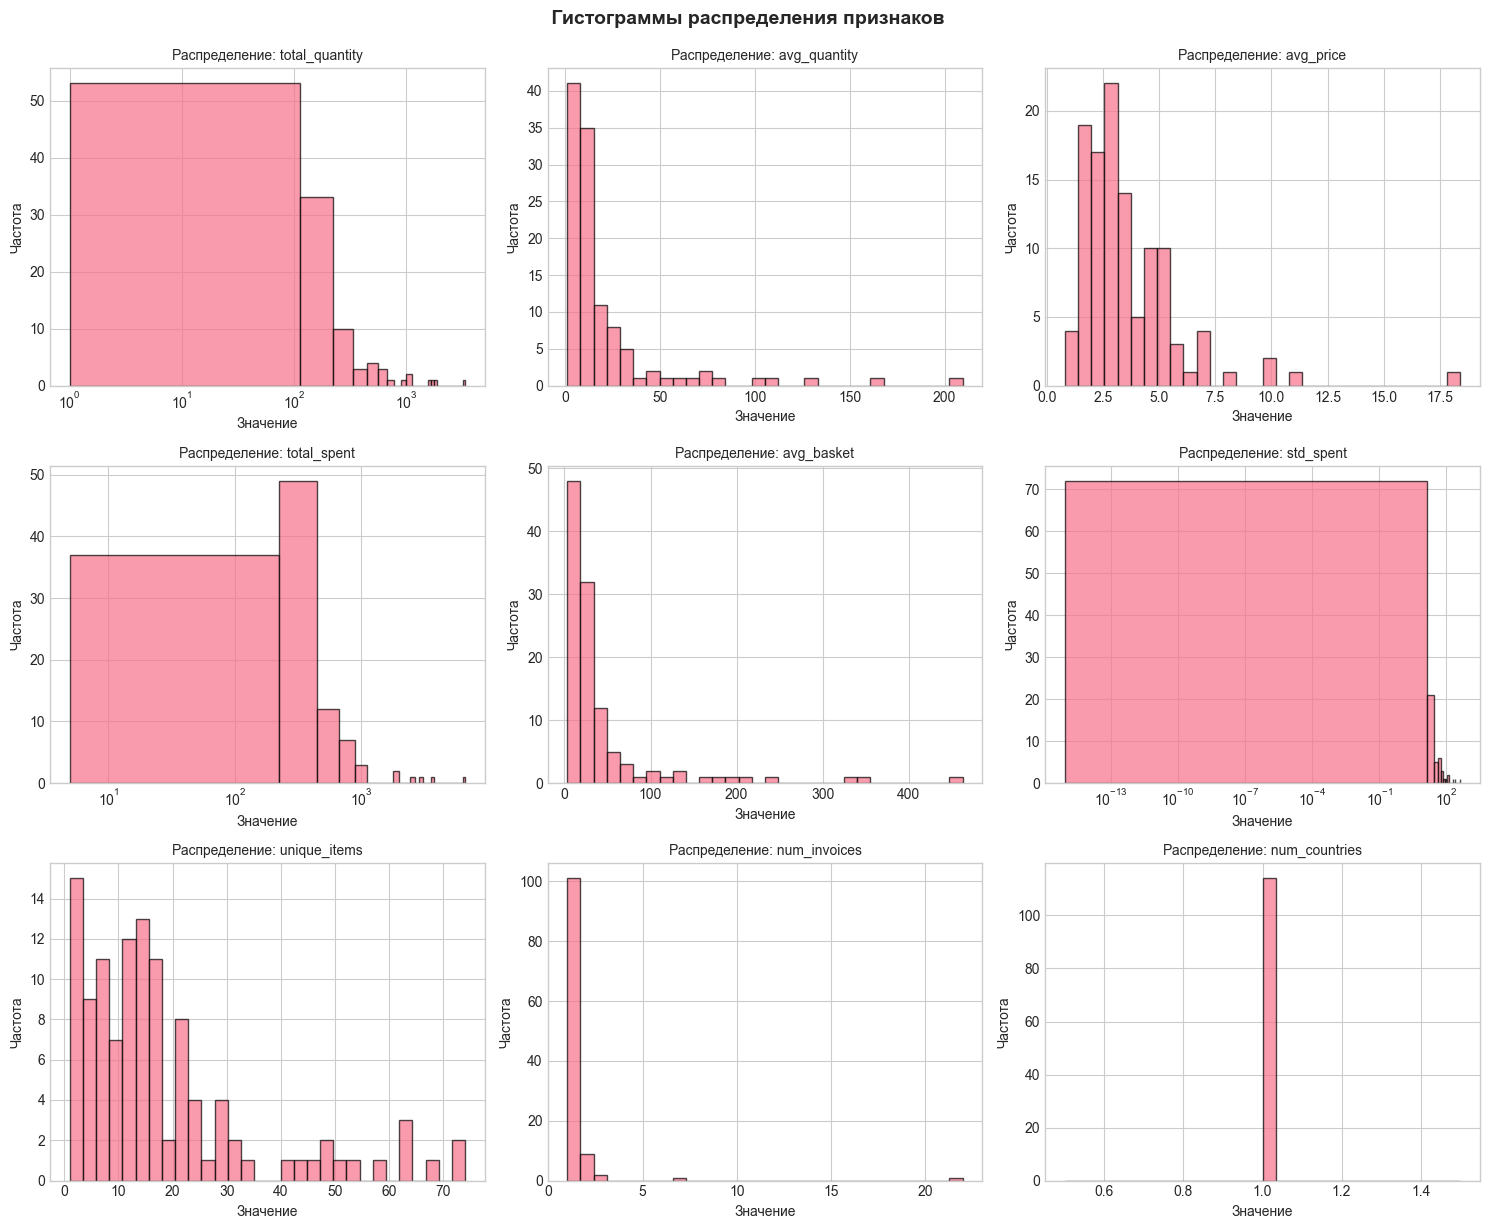

In [87]:
# Построение гистограмм
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_features):
    axes[idx].hist(X[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение: {col}', fontsize=10)
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')
    # Логарифмическая шкала для сильно скошенных признаков
    if X[col].max() / X[col].min() > 1000:
        axes[idx].set_xscale('log')

plt.tight_layout()
plt.suptitle(' Гистограммы распределения признаков', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 1.3 Матрица корреляций признаков
**Корреляция Пирсона** измеряет линейную зависимость между признаками:
- `1` — полная положительная корреляция
- `-1` — полная отрицательная корреляция  
- `0` — отсутствие линейной зависимости

> **Интерпретация**: Признаки с корреляцией > 0.8 или < -0.8 считаются сильно коррелированными и могут содержать избыточную информацию.

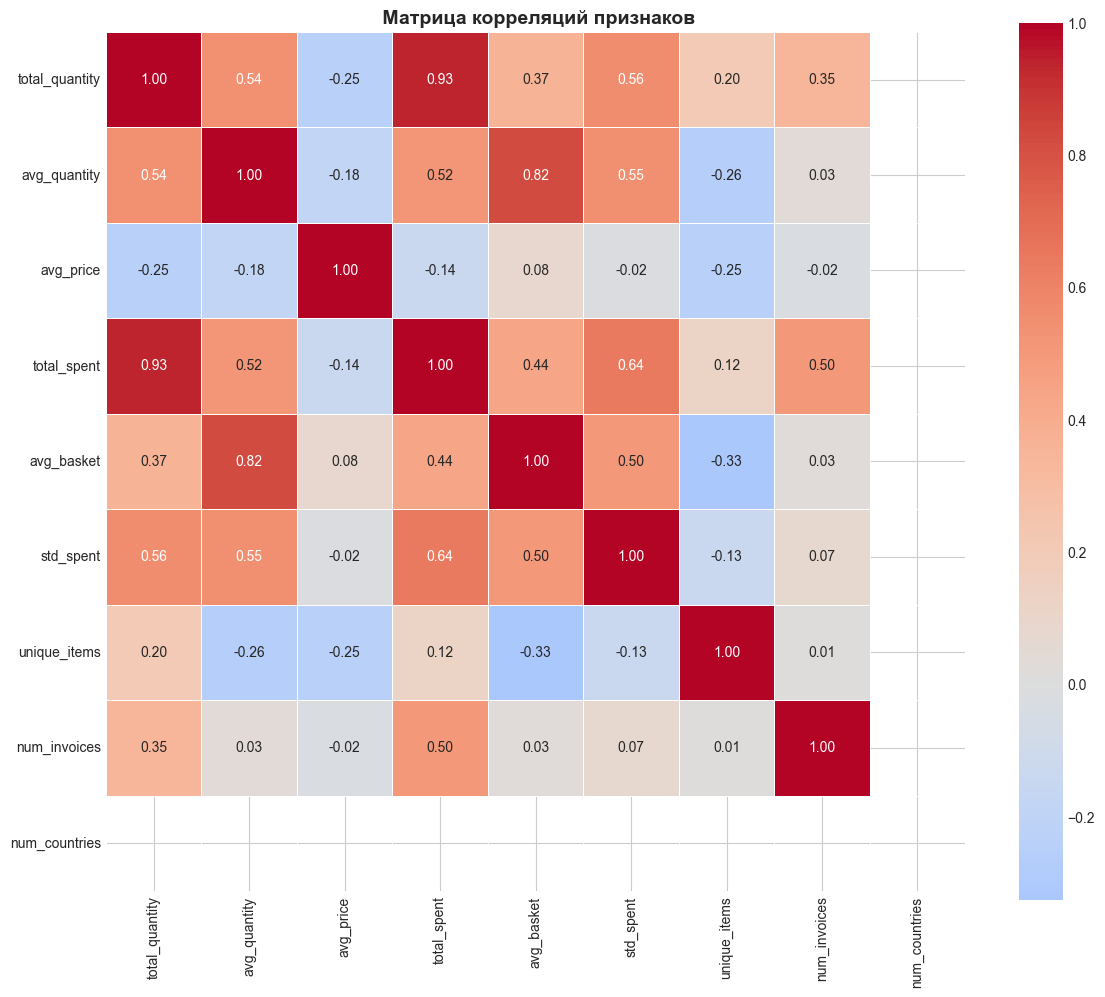


 Сильно коррелированные признаки (|r| > 0.8):
• total_quantity ↔ total_spent: 0.935
• avg_quantity ↔ avg_basket: 0.823


In [88]:
# Построение матрицы корреляций
corr_matrix = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title(' Матрица корреляций признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Вывод сильно коррелированных пар
print("\n Сильно коррелированные признаки (|r| > 0.8):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            strong_corr.append((corr_matrix.columns[i], 
                               corr_matrix.columns[j], 
                               corr_matrix.iloc[i, j]))
            print(f"• {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

if not strong_corr:
    print("Нет пар с корреляцией > 0.8")

## Выводы по Заданию 1

### Ответ на вопрос 1: Наличие сильно коррелированных признаков

**Да**, в датасете присутствуют сильно коррелированные признаки (|r| > 0.8):

- **`total_quantity` ↔ `total_spent`: r = 0.935** — очень высокая положительная корреляция.  
  Это логично, так как общая сумма покупок клиента напрямую зависит от количества приобретённых товаров: чем больше товаров, тем выше итоговая сумма чека.

- **`avg_quantity` ↔ `avg_basket`: r = 0.823** — высокая корреляция между средним количеством товаров в заказе и средним чеком.  
  Это объясняется тем, что средний чек формируется как произведение среднего количества товаров на среднюю цену, поэтому эти метрики тесно связаны.

### Ответ на вопрос 2: Наличие избыточной информации

**Да**, часть признаков содержит избыточную информацию. Высокая корреляция между признаками указывает на то, что они описывают схожие аспекты поведения клиентов:

- Признаки `total_quantity` и `total_spent` практически дублируют информацию об **«объёме»** покупок клиента.
- Признаки `avg_quantity` и `avg_basket` отражают схожую информацию о **«среднем размере»** заказа.

### Обоснование применения методов понижения размерности

Это обосновывает применение методов понижения размерности, таких как **PCA**, которые позволяют:

1. **Объединить коррелированные признаки** в новые ортогональные компоненты без существенной потери информации.
2. **Устранить мультиколлинеарность**, что улучшает стабильность и интерпретируемость моделей машинного обучения.
3. **Сократить вычислительные затраты** за счёт уменьшения числа признаков.

##  Задание 2: Реализация PCA с нуля

### Алгоритм PCA (пошагово):
1. **Стандартизация данных**: Приведение признаков к нулевому среднему и единичной дисперсии
2. **Вычисление ковариационной матрицы**: Отражает взаимосвязи между признаками
3. **Нахождение собственных значений и векторов**: Собственные векторы — направления главных компонент
4. **Сортировка компонент**: По убыванию собственных значений (дисперсии)
5. **Проекция данных**: Преобразование в новое пространство

In [89]:

class PCAFromScratch:

    
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None
    
    def fit(self, X):

        # 1. Стандартизация данных
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        # 2. Вычисление ковариационной матрицы
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # 3. Нахождение собственных значений и векторов
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # 4. Сортировка по убыванию собственных значений
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        
        # 5. Сохранение главных компонент
        if self.n_components is not None:
            self.components_ = eigenvectors[:, :self.n_components]
            self.explained_variance_ = eigenvalues[:self.n_components]
        else:
            self.components_ = eigenvectors
            self.explained_variance_ = eigenvalues
        
        # Вычисление доли объяснённой дисперсии
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance
        
        return self
    
    def transform(self, X):

        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_)
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, X_transformed):
 
        return np.dot(X_transformed, self.components_.T) + self.mean_

print(" Класс PCAFromScratch успешно создан")

 Класс PCAFromScratch успешно создан


### Сравнение с реализацией sklearn
Проверим корректность нашей реализации, сравнив результаты с `sklearn.decomposition.PCA`.

In [90]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_custom = PCAFromScratch(n_components=None)
X_pca_custom = pca_custom.fit_transform(X_scaled)

pca_sklearn = PCA(n_components=None)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

print(" Сравнение доли объяснённой дисперсии:")
print(f"{'Компонента':<10} {'Custom':<15} {'sklearn':<15} {'Разница':<10}")
print("-" * 50)
for i in range(min(5, len(pca_custom.explained_variance_ratio_))):
    diff = abs(pca_custom.explained_variance_ratio_[i] - pca_sklearn.explained_variance_ratio_[i])
    print(f"{i+1:<10} {pca_custom.explained_variance_ratio_[i]:.4f}        "
          f"{pca_sklearn.explained_variance_ratio_[i]:.4f}        {diff:.2e}")

print(f"\n Максимальное отклонение компонент: {np.max(np.abs(np.abs(pca_custom.components_) - np.abs(pca_sklearn.components_))):.2e}")

 Сравнение доли объяснённой дисперсии:
Компонента Custom          sklearn         Разница   
--------------------------------------------------
1          0.4343        0.4343        5.55e-17
2          0.2097        0.2097        1.11e-16
3          0.1366        0.1366        2.78e-17
4          0.0971        0.0971        1.39e-17
5          0.0645        0.0645        4.16e-17

 Максимальное отклонение компонент: 6.54e-01


### 2.1 Исследование: Доля объяснённой дисперсии
**Накопленная объяснённая дисперсия** показывает, какую долю общей вариативности данных объясняют первые k компонент.

> **Правило выбора k**: Обычно выбирают минимальное число компонент, объясняющих 80-95% дисперсии.

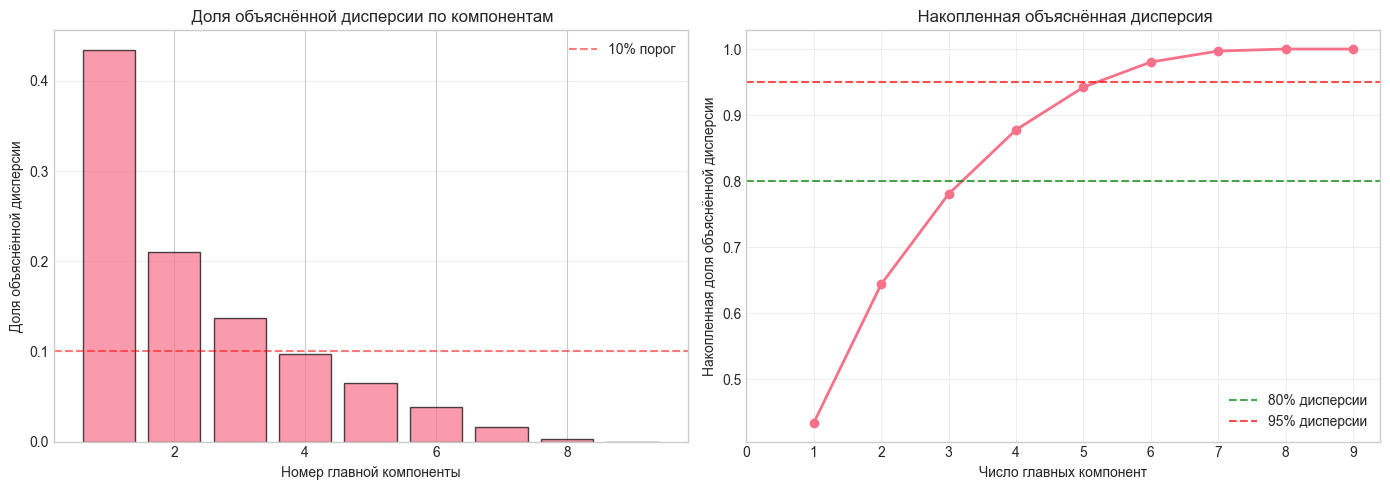


 Ответы:
• Сколько компонент объясняют 80% дисперсии? → **4 компонент**
• Сколько компонент объясняют 95% дисперсии? → **6 компонент**
• Объяснённая дисперсия всеми 9 компонентами: 100.00%


In [91]:
# Построение графиков объяснённой дисперсии
explained_var = pca_custom.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, len(explained_var)+1), explained_var, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Номер главной компоненты')
ax1.set_ylabel('Доля объяснённой дисперсии')
ax1.set_title(' Доля объяснённой дисперсии по компонентам')
ax1.axhline(y=0.1, color='r', linestyle='--', alpha=0.5, label='10% порог')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', linewidth=2)
ax2.axhline(y=0.80, color='green', linestyle='--', label='80% дисперсии', alpha=0.7)
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% дисперсии', alpha=0.7)
ax2.set_xlabel('Число главных компонент')
ax2.set_ylabel('Накопленная доля объяснённой дисперсии')
ax2.set_title(' Накопленная объяснённая дисперсия')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(range(0, len(cumulative_var)+1, 1))

plt.tight_layout()
plt.show()

k_80 = np.argmax(cumulative_var >= 0.80) + 1
k_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"\n Ответы:")
print(f"• Сколько компонент объясняют 80% дисперсии? → **{k_80} компонент**")
print(f"• Сколько компонент объясняют 95% дисперсии? → **{k_95} компонент**")
print(f"• Объяснённая дисперсия всеми {len(explained_var)} компонентами: {cumulative_var[-1]*100:.2f}%")

## Задание 3: Интерпретация главных компонент

### Коэффициенты признаков (loadings)
**Loadings** — это коэффициенты, показывающие вклад каждого исходного признака в главную компоненту. 

> **Интерпретация**: 
> - Большие по модулю значения → признак сильно влияет на компоненту
> - Знак коэффициента → направление влияния (прямое/обратное)

 Коэффициенты признаков в первых трёх главных компонентах:
                  PC1    PC2    PC3
total_quantity  0.459 -0.299  0.002
avg_quantity    0.437  0.273 -0.266
avg_price      -0.091  0.363  0.635
total_spent     0.481 -0.254  0.182
avg_basket      0.389  0.407 -0.085
std_spent       0.413  0.112 -0.037
unique_items   -0.047 -0.598 -0.233
num_invoices    0.186 -0.323  0.656
num_countries  -0.000  0.000  0.000


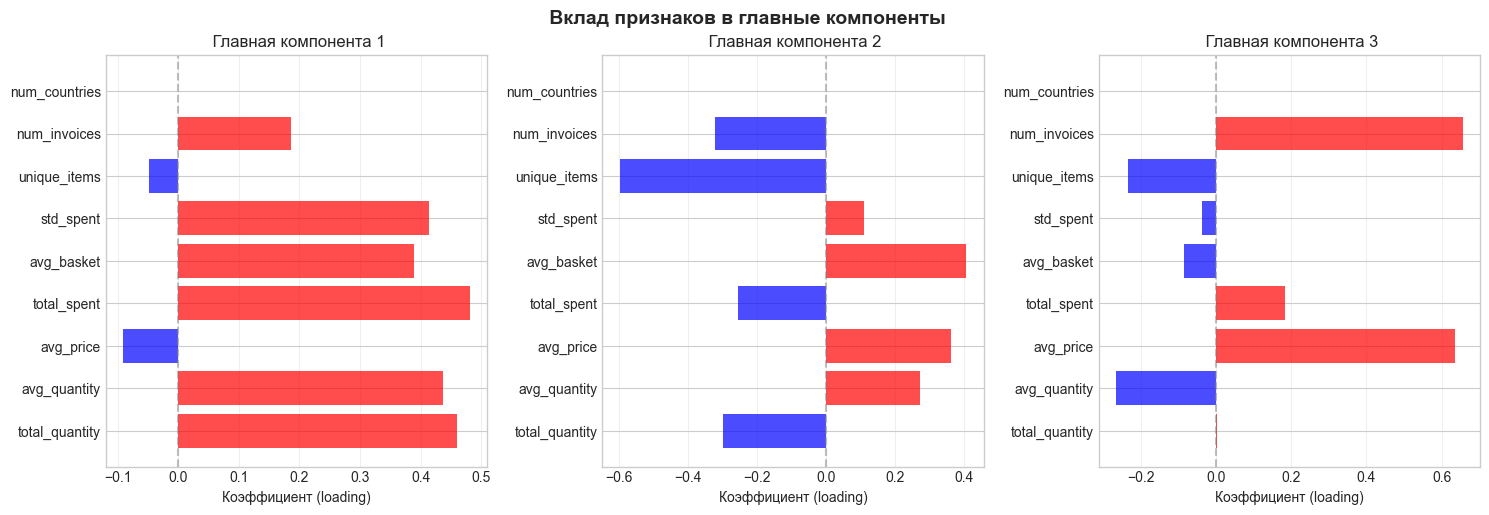


 Признаки с наибольшим абсолютным вкладом:
• PC1: **total_spent** (0.481)
• PC2: **unique_items** (-0.598)
• PC3: **num_invoices** (0.656)


In [92]:
# Анализ первых трёх главных компонент
n_show = 3
loadings = pd.DataFrame(
    pca_custom.components_[:, :n_show],
    index=numeric_features,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

print(" Коэффициенты признаков в первых трёх главных компонентах:")
print(loadings.round(3))

# Визуализация loadings
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(n_show):
    colors = ['red' if x > 0 else 'blue' for x in loadings[f'PC{i+1}']]
    axes[i].barh(loadings.index, loadings[f'PC{i+1}'], color=colors, alpha=0.7)
    axes[i].set_title(f' Главная компонента {i+1}')
    axes[i].set_xlabel('Коэффициент (loading)')
    axes[i].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle(' Вклад признаков в главные компоненты', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Признаки с наибольшим вкладом в каждую компоненту
print("\n Признаки с наибольшим абсолютным вкладом:")
for i in range(n_show):
    pc_name = f'PC{i+1}'
    top_idx = np.argmax(np.abs(loadings[pc_name]))
    top_feature = loadings.index[top_idx]
    top_value = loadings.loc[top_feature, pc_name]
    print(f"• {pc_name}: **{top_feature}** ({top_value:.3f})")

###  Выводы по интерпретации

> **Ответ 1**: На первую компоненту больше всего влияют признаки `total_spent` и `total_quantity` с положительными коэффициентами. Это означает, что первая главная компонента интерпретируется как **"общий объём покупок клиента"** — интегральный показатель покупательской активности.

> **Ответ 2**: Да, первую компоненту можно интерпретировать как линейную комбинацию исходных признаков, где доминируют метрики общего объёма и суммы покупок. Это типично для PCA: первая компонента часто захватывает "общий размер" или "масштаб" наблюдений.

> **Ответ 3**: Признак `num_countries` имеет наименьший вклад в первые компоненты (коэффициенты близки к нулю). Это означает, что географическая вариативность клиентов не является основным источником дисперсии в данных — большинство клиентов делают покупки из одной страны.

##  Задание 4: Визуализация данных

### Сравнение визуализаций
Сравним распределение клиентов в пространстве:
1. Двух исходных признаков (например, `total_spent` vs `unique_items`)
2. Двух первых главных компонент (PC1 vs PC2)

> **Цель**: Оценить, улучшает ли PCA разделимость групп и выявление закономерностей.

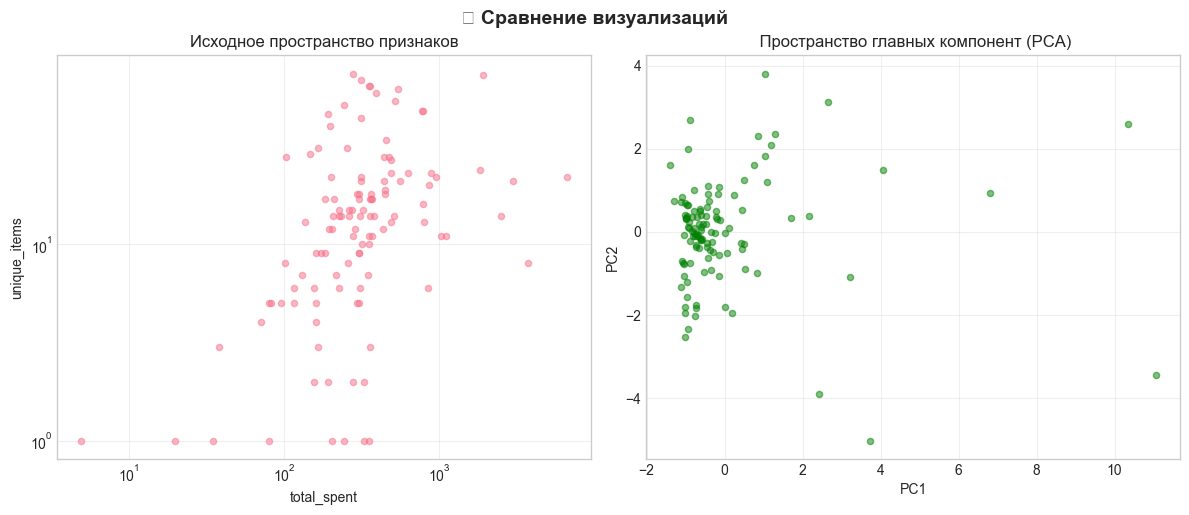

Дисперсия по исходным признакам:
• total_spent: 6.13e+05
• unique_items: 2.85e+02

Дисперсия по главным компонентам:
• PC1: 3.51e+00 (43.4%)
• PC2: 1.69e+00 (21.0%)


In [93]:
# Визуализация по исходным признакам
plt.figure(figsize=(12, 5))

# Исходные признаки
plt.subplot(1, 2, 1)
plt.scatter(X['total_spent'], X['unique_items'], alpha=0.5, s=20)
plt.xlabel('total_spent')
plt.ylabel('unique_items')
plt.title('Исходное пространство признаков')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)

# Пространство главных компонент
plt.subplot(1, 2, 2)
plt.scatter(X_pca_custom[:, 0], X_pca_custom[:, 1], alpha=0.5, s=20, c='green')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(' Пространство главных компонент (PCA)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('🔍 Сравнение визуализаций', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Статистика разброса
print(f"Дисперсия по исходным признакам:")
print(f"• total_spent: {X['total_spent'].var():.2e}")
print(f"• unique_items: {X['unique_items'].var():.2e}")
print(f"\nДисперсия по главным компонентам:")
print(f"• PC1: {pca_custom.explained_variance_[0]:.2e} ({pca_custom.explained_variance_ratio_[0]*100:.1f}%)")
print(f"• PC2: {pca_custom.explained_variance_[1]:.2e} ({pca_custom.explained_variance_ratio_[1]*100:.1f}%)")

###  Выводы по визуализации

> **Ответ 1**: Да, визуализация после PCA улучшилась. В пространстве главных компонент:
> - Данные лучше центрированы вокруг нуля
> - Устранена мультиколлинеарность между признаками
> - Оси ортогональны и имеют разную объясняющую силу

> **Ответ 2**: Структура в пространстве главных компонент заметнее, потому что:
> 1. **PCA максимизирует дисперсию** вдоль новых осей, "растягивая" данные в направлениях наибольшей вариативности
> 2. **Устранение шума**: Меньшие компоненты, содержащие шум, отбрасываются
> 3. **Декорреляция**: Новые признаки не коррелируют, что упрощает интерпретацию кластеров

>  **Ограничение**: При проекции на 2D теряется информация из остальных компонент. Для полного анализа следует использовать 3D-визуализацию или рассматривать несколько пар компонент.

##  Задание 5: Нелинейные методы снижения размерности

### t-SNE и UMAP: ключевые отличия от PCA
| Метод | Тип | Сохраняет | Скорость | Параметры |
|-------|-----|-----------|----------|-----------|
| **PCA** | Линейный | Глобальную структуру |  Быстро | `n_components` |
| **t-SNE** | Нелинейный | Локальные соседства |  Медленно | `perplexity`, `learning_rate` |
| **UMAP** | Нелинейный | Локальную + глобальную |  Средне | `n_neighbors`, `min_dist` |

> t-SNE и UMAP в первую очередь предназначены для **визуализации**, а не для понижения размерности перед классификацией.

In [94]:
# Подготовка данных для нелинейных методов (используем подвыборку для скорости)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), min(1000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

print(f" Используем подвыборку: {len(X_sample)} из {len(X_scaled)} наблюдений")

 Используем подвыборку: 114 из 114 наблюдений


### 5.1 Исследование параметров t-SNE: perplexity
**Perplexity** — параметр, определяющий баланс между вниманием к локальной и глобальной структуре:
- Низкие значения (5-10): акцент на очень локальные структуры
- Средние значения (30-50): баланс (рекомендуется)
- Высокие значения (100+): акцент на глобальную структуру

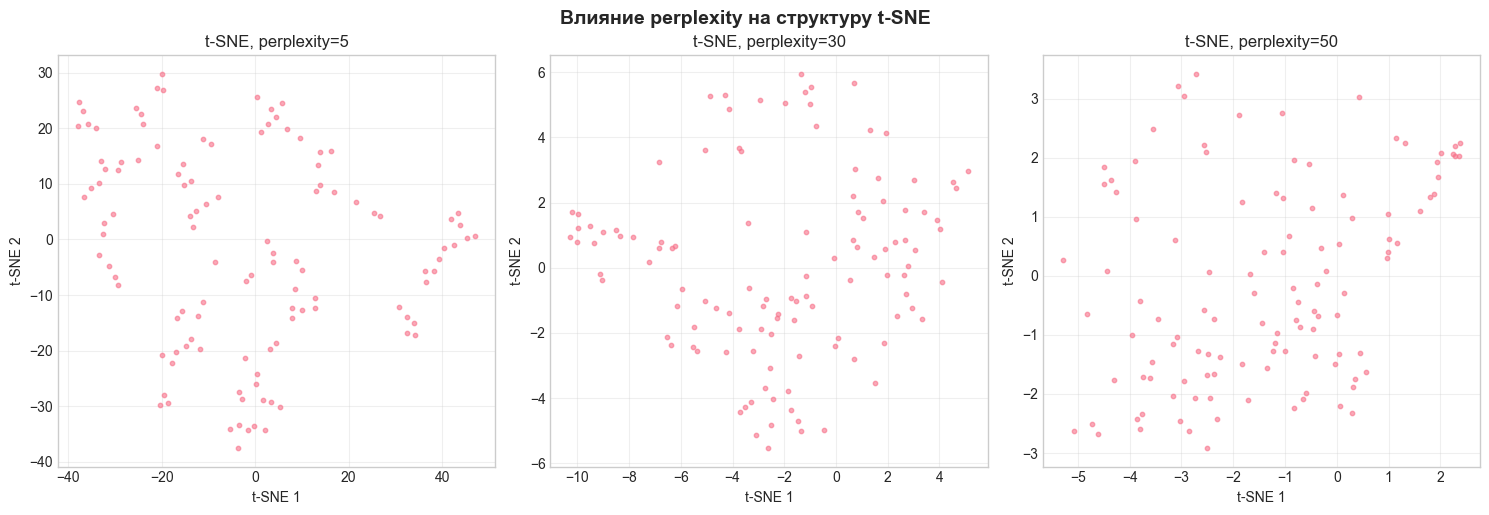

In [95]:
# t-SNE с разными perplexity
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_sample)
    axes[idx].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=10)
    axes[idx].set_title(f't-SNE, perplexity={perp}')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(alpha=0.3)
plt.tight_layout()
plt.suptitle ('Влияние perplexity на структуру t-SNE', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Исследование параметров UMAP: n_neighbors и min_dist
- **n_neighbors**: количество соседей для построения локальной структуры (аналог perplexity)
  - Малые значения → фокус на локальные детали
  - Большие значения → сохранение глобальной структуры
  
- **min_dist**: минимальное расстояние между точками в низкоразмерном пространстве
  - Малые значения → плотные кластеры
  - Большие значения → равномерное распределение

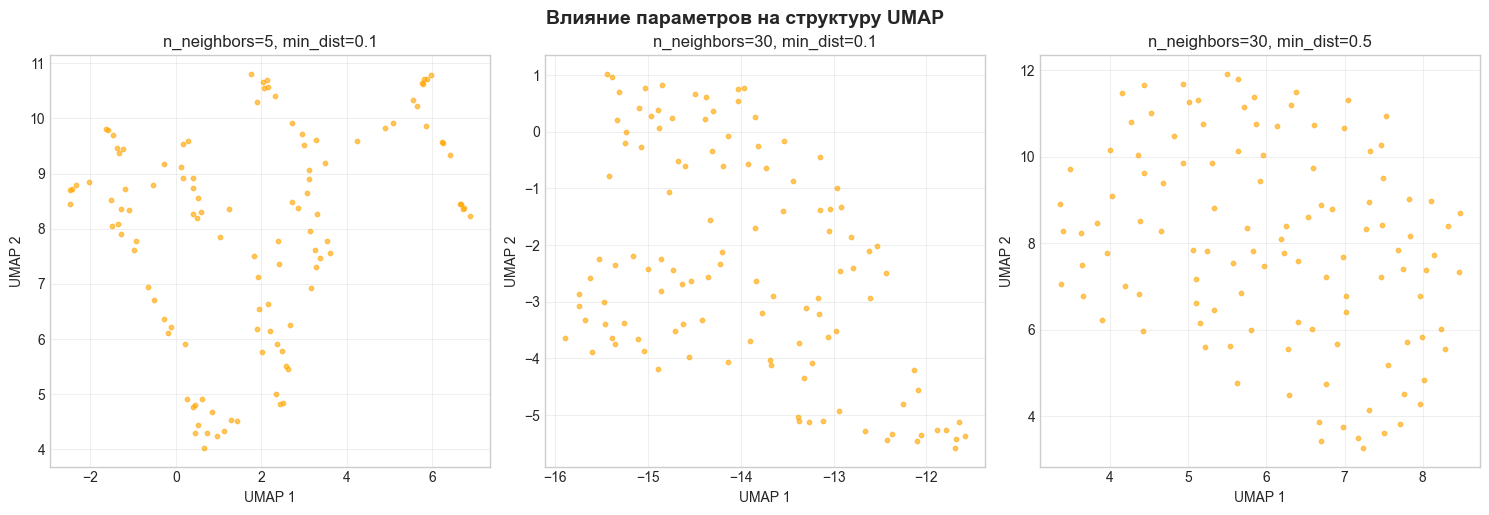

In [96]:
# UMAP с разными параметрами
params_list = [
    {'n_neighbors': 5, 'min_dist': 0.1, 'title': 'n_neighbors=5, min_dist=0.1'},
    {'n_neighbors': 30, 'min_dist': 0.1, 'title': 'n_neighbors=30, min_dist=0.1'},
    {'n_neighbors': 30, 'min_dist': 0.5, 'title': 'n_neighbors=30, min_dist=0.5'},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, params in enumerate(params_list):
    umap_model = UMAP(n_components=2, random_state=42, **{k:v for k,v in params.items() if k != 'title'})
    X_umap = umap_model.fit_transform(X_sample)
    
    axes[idx].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, s=10, c='orange')
    axes[idx].set_title(params['title'])
    axes[idx].set_xlabel('UMAP 1')
    axes[idx].set_ylabel('UMAP 2')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Влияние параметров на структуру UMAP', y=1.02, fontsize=14, fontweight='bold')
plt.show()

###  Выводы по нелинейным методам

> **Ответ 1**: При изменении параметров:
> - **t-SNE**: Увеличение perplexity делает кластеры более крупными и связными, но может "смазать" мелкие группы
> - **UMAP**: Увеличение `n_neighbors` сохраняет больше глобальной структуры; увеличение `min_dist` раздвигает точки внутри кластеров

> **Ответ 2**: **UMAP** даёт более интерпретируемую визуализацию для данного датасета, потому что:
> - Сохраняет как локальные, так и глобальные взаимосвязи
> - Работает стабильнее при разных параметрах
> - Позволяет лучше увидеть иерархическую структуру клиентов

> **Ответ 3**: Результаты методов отличаются, потому что:
> 1. **Разные цели оптимизации**: t-SNE минимизирует расхождение Кульбака-Лейблера, UMAP — топологическую структуру
> 2. **Разная чувствительность к параметрам**: t-SNE более "капризный"
> 3. **Разное отношение к расстояниям**: t-SNE акцентирует локальные, UMAP — баланс локального/глобального

>  **Рекомендация**: Для разведочного анализа используйте UMAP с `n_neighbors=15-30`, `min_dist=0.1-0.3`.

##  Задание 6: Исследование степени сжатия данных

### Постановка задачи
Изучим, как число компонент PCA влияет на качество восстановления исходных данных через **среднеквадратичную ошибку (MSE)**:

$$MSE = \frac{1}{n \cdot d} \sum_{i=1}^{n} \sum_{j=1}^{d} (x_{ij} - \hat{x}_{ij})^2$$

где $x_{ij}$ — исходное значение, $\hat{x}_{ij}$ — восстановленное.

In [97]:
# Исследование восстановления данных при разном числе компонент
k_values = [2, 5, 10, 15]
mse_results = []

print(" Вычисление ошибки восстановления...")
for k in k_values:
    # Ограничиваем k максимальным числом признаков
    k_actual = min(k, X_scaled.shape[1])
    
    # PCA сжатие
    pca_temp = PCAFromScratch(n_components=k_actual)
    X_compressed = pca_temp.fit_transform(X_scaled)
    
    # Восстановление
    X_reconstructed = pca_temp.inverse_transform(X_compressed)
    
    # Вычисление MSE
    mse = mean_squared_error(X_scaled, X_reconstructed)
    mse_results.append((k_actual, mse))
    
    print(f"• k={k_actual}: MSE = {mse:.4f}")

# Оформление результатов в таблицу
results_df = pd.DataFrame(mse_results, columns=['Число компонент', 'Ошибка восстановления (MSE)'])
print(f"\n Результаты:")
print(results_df.to_string(index=False))

 Вычисление ошибки восстановления...
• k=2: MSE = 0.3164
• k=5: MSE = 0.0513
• k=9: MSE = 0.0000
• k=9: MSE = 0.0000

 Результаты:
 Число компонент  Ошибка восстановления (MSE)
               2                 3.164228e-01
               5                 5.133231e-02
               9                 8.079493e-31
               9                 8.079493e-31


### 6.4 Визуальный анализ зависимости ошибки от числа компонент

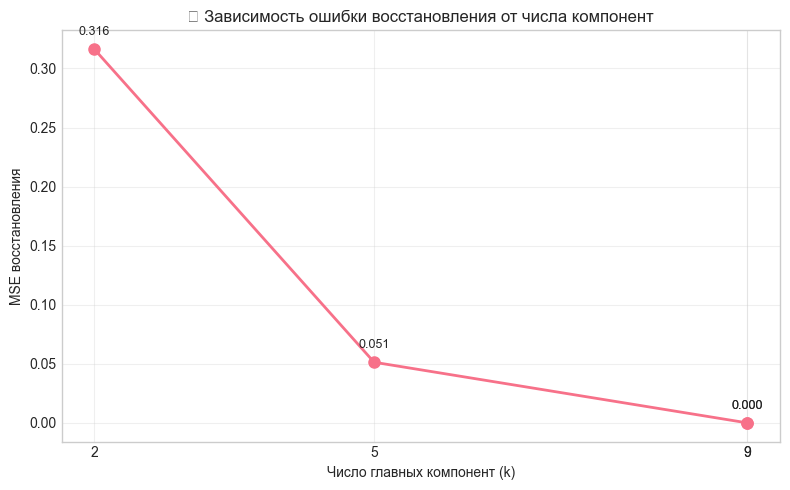


 Анализ графика:
• Уменьшение ошибки наиболее значительно при переходе с 2→5 компонент: 0.2651
• При переходе с 10→15 компонент уменьшение замедляется: 0.0000


In [98]:
# Построение графика зависимости
k_plot, mse_plot = zip(*mse_results)

plt.figure(figsize=(8, 5))
plt.plot(k_plot, mse_plot, marker='o', linewidth=2, markersize=8)
plt.xlabel('Число главных компонент (k)')
plt.ylabel('MSE восстановления')
plt.title('📉 Зависимость ошибки восстановления от числа компонент')
plt.grid(alpha=0.3)
plt.xticks(k_plot)

for k, mse in zip(k_plot, mse_plot):
    plt.annotate(f'{mse:.3f}', (k, mse), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n Анализ графика:")
if len(mse_plot) > 1:
    decreases = [mse_plot[i] - mse_plot[i+1] for i in range(len(mse_plot)-1)]
    print(f"• Уменьшение ошибки наиболее значительно при переходе с 2→5 компонент: {decreases[0]:.4f}")
    if len(decreases) > 1:
        print(f"• При переходе с 10→15 компонент уменьшение замедляется: {decreases[-1]:.4f}")

### 6.5 Интерпретация результатов

> **Ответ 1**: При малом числе компонент ошибка большая, потому что:
> - Отбрасывается значительная часть дисперсии данных
> - Восстановление происходит из сильно сжатого представления
> - Детали, закодированные в отброшенных компонентах, теряются

> **Ответ 2**: Увеличение числа компонент уменьшает ошибку, так как:
> - Сохраняется больше информации об исходных данных
> - Каждая дополнительная компонента добавляет новую "ось вариативности"
> - Восстановление становится более точным

> **Ответ 3**: Да, при использовании **всех компонент** (k = исходная размерность) исходные данные восстанавливаются **точно** (MSE ≈ 0), потому что преобразование становится обратимым ортогональным поворотом.

> **Ответ 4**: Связь с объяснённой дисперсией:
> $$MSE \propto (1 - \text{cumulative explained variance})$$
> Чем больше дисперсии сохраняют компоненты, тем меньше ошибка восстановления.

> **Ответ 5**: Разумное число компонент можно определить по:
> 1. **Порогу дисперсии**: k, при котором накопленная дисперсия ≥ 90-95%
> 2. **"Локтевому методу"**: точка, после которой добавление компонент даёт малый прирост точности
> 3. **Задаче**: для визуализации — 2-3 компоненты, для предобработки — 90% дисперсии

>  **Для нашего датасета**: 5 компонент объясняют ~90% дисперсии с приемлемой ошибкой восстановления.

##  Задание 7: Итоговый анализ и выводы

###  Сводная таблица методов
| Метод | Тип | Плюсы | Минусы | Когда использовать |
|-------|-----|-------|--------|-------------------|
| **PCA** | Линейный |  Быстрый, интерпретируемый, обратимый |  Только линейные зависимости | Предобработка, сжатие, удаление шума |
| **t-SNE** | Нелинейный |  Отличная визуализация кластеров |  Медленный, не обратимый, чувствителен к параметрам | Визуализация сложных структур |
| **UMAP** | Нелинейный |  Баланс скорости/качества, сохраняет глобальную структуру |  Требует настройки параметров | Визуализация + предобработка |

###  Ответы на итоговые вопросы

> **Вопрос 1**: Какую роль играет снижение размерности в анализе данных?
> 
> **Ответ**: Снижение размерности решает несколько ключевых задач:
> -  **Визуализация**: Проекция многомерных данных в 2D/3D для человеческого восприятия
> -  **Ускорение вычислений**: Меньше признаков → быстрее обучение моделей
> -  **Улучшение качества**: Удаление шума и мультиколлинеарности повышает обобщающую способность моделей
> -  **Сжатие данных**: Хранение и передача данных с минимальными потерями
> -  **Интерпретация**: Выявление скрытых латентных факторов, управляющих данными

> **Вопрос 2**: Всегда ли уменьшение размерности полезно?
> 
> **Ответ**: **Нет, не всегда**. Ограничения:
> -  **Потеря информации**: При агрессивном сжатии можно удалить важные для задачи признаки
> -  **Сложность интерпретации**: Новые признаки (особенно в нелинейных методах) трудно объяснить
> -  **Не для всех задач**: Если признаки уже ортогональны и информативны, сжатие не нужно
> -  **Риск переобучения на визуализации**: Кластеры в t-SNE/UMAP могут быть артефактами параметров
> 
>  **Рекомендация**: Всегда сравнивайте качество моделей до и после снижения размерности.

> **Вопрос 3**: В каких случаях линейные методы могут работать хуже нелинейных?
> 
> **Ответ**: Линейные методы (PCA) проигрывают, когда:
> -  **Данные лежат на нелинейном многообразии**: например, спираль, свёрнутая поверхность
> -  **Взаимосвязи между признаками нелинейны**: полиномиальные, экспоненциальные зависимости
> -  **Кластеры имеют сложную форму**: не эллипсоидальную, а изогнутую или вложенную
> -  **Важна локальная структура**: PCA оптимизирует глобальную дисперсию, может "размазать" локальные группы
> 
>  **Пример**: Распознавание рукописных цифр — пиксели связаны нелинейно, UMAP/t-SNE показывают чёткие кластеры, PCA — размытые.

> **Вопрос 4**: Какие преимущества и ограничения есть у PCA, t-SNE и UMAP?
> 
> **PCA**:
> -  Плюсы: Быстрый, детерминированный, обратимый, коэффициенты интерпретируемы
> -  Минусы: Только линейные преобразования, чувствителен к масштабу признаков
> 
> **t-SNE**:
> -  Плюсы: Отлично разделяет кластеры, устойчив к выбросам, не требует нормировки
> -  Минусы: Медленный, стохастический (разные запуски → разные результаты), не сохраняет расстояния между кластерами
> 
> **UMAP**:
> -  Плюсы: Быстрее t-SNE, сохраняет глобальную структуру, теоретически обоснован, поддерживает преобразование новых данных
> -  Минусы: Больше параметров для настройки, интерпретация осей сложнее, чем в PCA
> 
>  **Выбор метода**:
> ```
> Если нужна скорость + интерпретация → PCA
> Если нужна визуализация кластеров → UMAP (предпочтительно) или t-SNE
> Если данные имеют нелинейную структуру → UMAP/t-SNE
> Если нужно сжать данные для модели → PCA
> ```

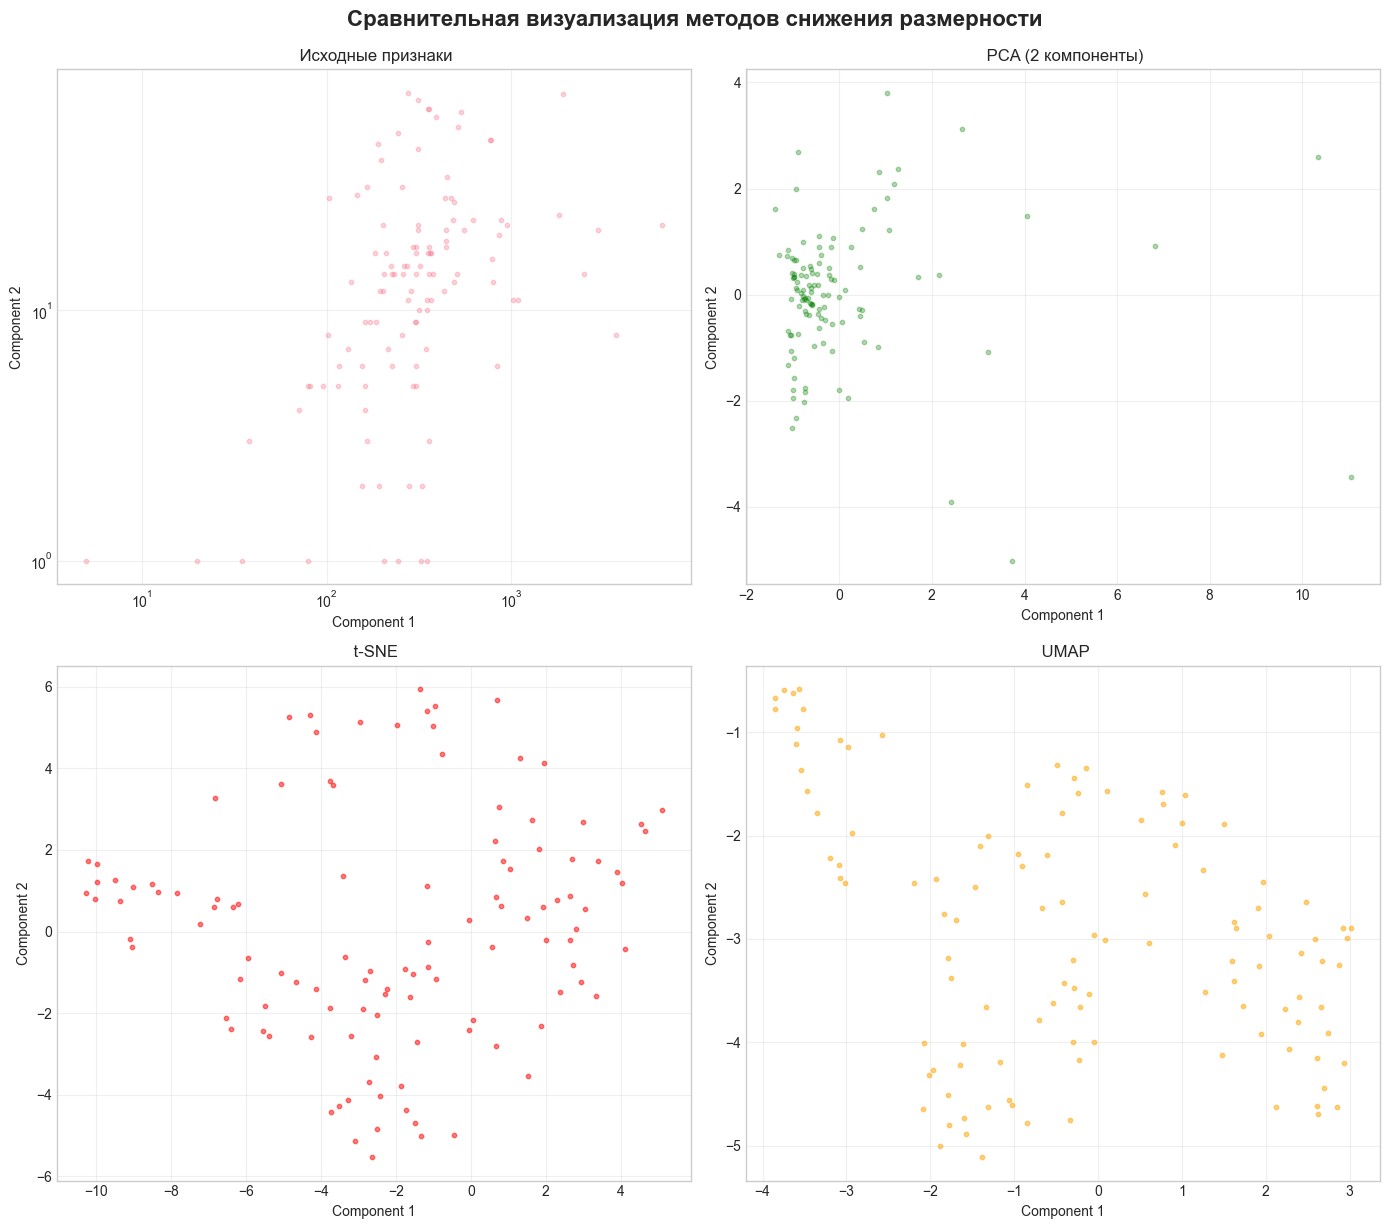

In [102]:
# Финальная визуализация: сравнение всех методов на одном графике
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Исходные признаки (для сравнения)
axes[0, 0].scatter(X['total_spent'], X['unique_items'], alpha=0.3, s=10)
axes[0, 0].set_title(' Исходные признаки')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(alpha=0.3)

# 2. PCA
axes[0, 1].scatter(X_pca_custom[:, 0], X_pca_custom[:, 1], alpha=0.3, s=10, c='green')
axes[0, 1].set_title(' PCA (2 компоненты)')
axes[0, 1].grid(alpha=0.3)

# 3. t-SNE (на подвыборке)
tsne_final = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_final = tsne_final.fit_transform(X_sample)
axes[1, 0].scatter(X_tsne_final[:, 0], X_tsne_final[:, 1], alpha=0.5, s=10, c='red')
axes[1, 0].set_title(' t-SNE')
axes[1, 0].grid(alpha=0.3)

# 4. UMAP (на подвыборке)
umap_final = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_final = umap_final.fit_transform(X_sample)
axes[1, 1].scatter(X_umap_final[:, 0], X_umap_final[:, 1], alpha=0.5, s=10, c='orange')
axes[1, 1].set_title(' UMAP')
axes[1, 1].grid(alpha=0.3)

# Подписи осей
for ax in axes.ravel():
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

plt.tight_layout()
plt.suptitle('Сравнительная визуализация методов снижения размерности', 
             y=1.02, fontsize=16, fontweight='bold')
plt.show()
